In [1]:
from earth_moving.scenarios.fedeoli_beavers_scenario import fedeoli_beavers_scenario

beavers_running_config = {
    'backend_type': 'beavers_visualizer',    
    'environment':
        {
          'name': 'beavers_environment',
          'map_mode': 'csv',
          'elevation_file_path': 'csv_analysis/output/elevation.npy',
        #   'elevation_file_path': 'outputs/maps/environment_map_explore_grass.npy',
          'latitude_file_path': 'csv_analysis/output/X_coordinates.npy',
          'longitude_file_path': 'csv_analysis/output/Y_coordinates.npy',
          'vegetation_quality_range': [0, 10],
          'grass_growth_rate': 1e-3,
          'grass_growth_interval': [0, 3],
          'visits_reset': 0.999,
          'flow_info': {
              'direction': [0, 0],
              'strength': 0.0,
              'streams_width': 10,  # depth
              'river_growth_velocity': 5e0,
          },
          'print': False,
        },
    'robot':
        {
            'name': 'beavers_robot',
            'position': 'random_home',
            'home_base_position': [[200,210]],
            'range_x': [-3, 3],
            'range_y': [-3, 3],            
            'initial_load': 0,                   
            'maximum_load': 20,
            'initial_energy': 100,               
            'motion_consumption': 0,             
            'load_consumption': 0,               
            'harvest_consumption': 0,            
            'harvest_threshold': [[-10,2]], 
            'vegetation_removal': 0.0,
            'stomping_interval': [0, 5],
            'stomping_removal': 1e-3,
            'sleep_recovery': 1,
            'measurement_mode': 'full_map',
            'exploration_mode': 'gradient_D100', #! HOW FAR CAN THE BEAVER SEE?
            'measure_step': 4,
            'exploration_eta': 1e2,
            'exploration_gaussian_locality_sigma': 1e3,
            'exploration_map': 'vegetation_quality', #! SET THE BEHAVIORAL LOGIC
            'n_traces': 30,
            'decay_values': [0.000, 0.000, 0.000], #! decay for [exploration_eta, harvest_threshold, maximum_load]
            'exploration_N_recovery': 10,
            'print': False,
            'controller': {                
                'name':'P_repulsive',
                'Kp': 1*1e-2,
                'Kd': 0*1e-1,
                'Ki': 1*5e-3,
                'neighbourhood_size': 2,                
                'max': 10.0,
                'accuracy': 1e-2,
                'dimension': 2,
                'map_repulsive': 'vegetation_quality', #! SET THE REPULSIVE MAP
                'beta_repulsive': 0.75,
            },
            'dynamics': {
                'name':'integrator',
                'mass':1.0,
                'friction':1.0
            }
        },
    'simulation':
        {
            'seed': 10,
            'timedelta': 1.0,
            'schedule_policy': 'sequential',
            'gui': True,
            'number_of_agents': 5,
            'print': True,
            'number_of_steps': 365*1,
            'downsampling': 7*24,
            'save_path': 'outputs/maps/environment_map_test.npy'
        },    
    }

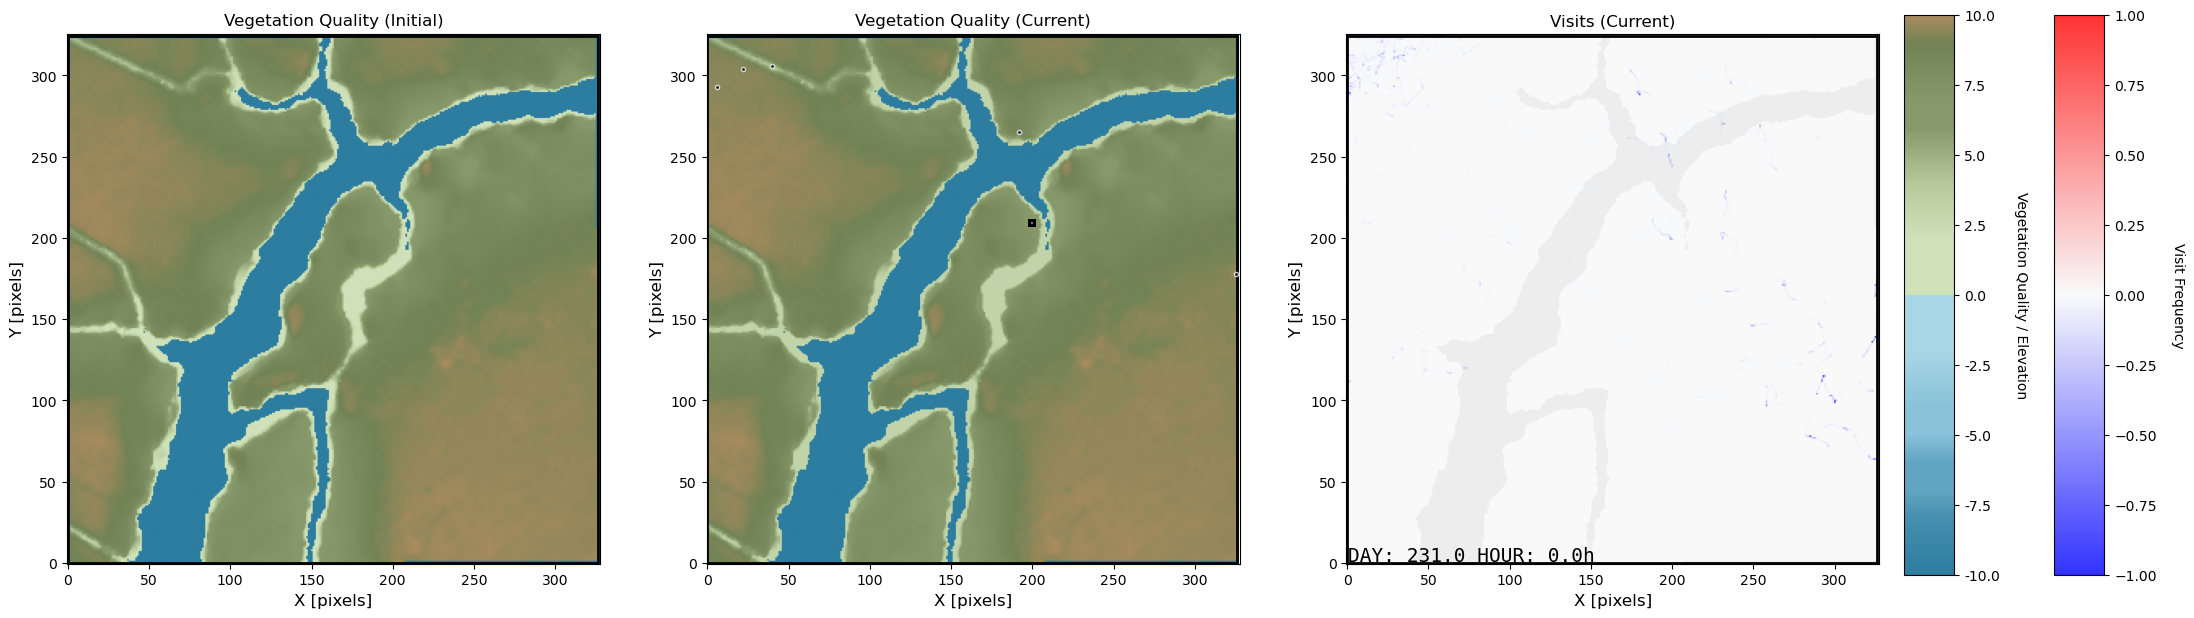

In [ ]:
fedeoli_beavers_scenario(beavers_running_config)